In [2]:
#Import modules
import scanpy as sc
import anndata as ad
import numpy as np

%pip install torch pyro-ppl

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import scipy.sparse as sp

# Silhouette scores
from sklearn.metrics import silhouette_score
import pandas as pd


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
#Read data
adata_source = '/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/Data/20260207_adata_preprocessed_full.h5ad'
adata = sc.read_h5ad(adata_source)

In [8]:
#Pre-process data
adata_dense = adata.X.toarray() #Convert to dense array, in case future functions/libraries don't support a sparse matrix
nut_fusion_col = 'NUT-fusion: 0 = unkwn; 1 = BRD4-NUT; 2 = BRD3-NUT; 3 = NSD3-NUT; 4 = ZNF532-NUT; 5 = ZNF592-NUT'

tumor_mask = adata.obs['cell_type_general'] == 'tumor'
brd4_mask = adata.obs[nut_fusion_col] == 1
adata_tumor = adata[tumor_mask & brd4_mask].copy()

# Separate into two pools: 479 and 480 only
adata_tma_479 = adata_tumor[adata_tumor.obs['TMA']==479].copy()
adata_tma_480 = adata_tumor[adata_tumor.obs['TMA']==480].copy()

adata_479_25k = sc.pp.subsample(adata_tma_479, n_obs=25000, random_state=5, copy=True)
adata_480_25k = sc.pp.subsample(adata_tma_480, n_obs=25000, random_state=5, copy=True)

adata_tumor_50k = sc.concat([adata_479_25k,adata_480_25k])

In [9]:
print(adata_tumor.obs['TMA'].value_counts())
print(f"Total BRD4-NUT tumor cells: {adata_tumor.n_obs}")

TMA
479    170465
480     67386
Name: count, dtype: int64
Total BRD4-NUT tumor cells: 237851


In [10]:
# Import decipher-bc: simple concatenation
import sys
sys.path.insert(0, '/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc')
import decipher as dc

/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/Data Analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
adata_tumor_dc=adata_tumor_50k.copy()
counts = adata_tumor_dc.layers['counts'].copy() #Decipher requires discrete integer counts, so we pull raw counts out of layers['counts']

# Block below fixes any floating point precision and writes back into adata.
if sp.issparse(counts):
    counts.data = counts.data.round().astype(int)
else:
    counts = counts.round().astype(int)
adata_tumor_dc.X = counts

In [12]:
#Lower learning rate
from decipher.tools._decipher import DecipherConfig
config = DecipherConfig(learning_rate=1e-4,seed=5)

Epoch 74 (batch 703/703) | | train elbo: 203.50 (last epoch: 203.47) | val ll: 217.29:   7%|▋         | 74/1000 [08:02<1:40:37,  6.52s/it]2026-05-20 13:19:58,581 | INFO : Early stopping has been triggered.
2026-05-20 13:19:58,632 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-05-20 13:19:58,633 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-05-20 13:19:58,639 | INFO : Saving decipher model with run_id 2026-05-20-13-19-58-organic-jolly-iteration.


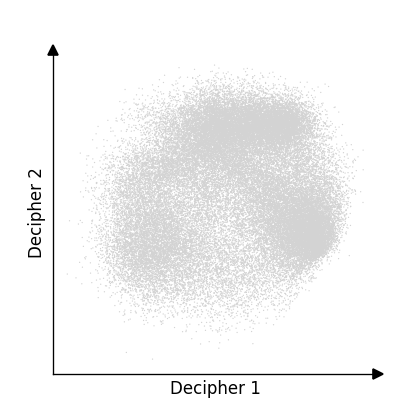

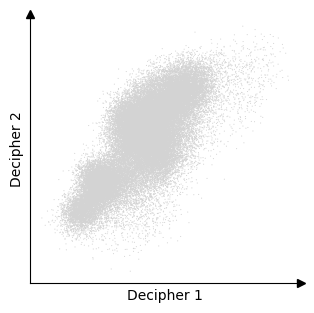

In [13]:
adata_tumor_dc_brd4_concat_sid = adata_tumor_dc.copy()

decipher_model_brd4_sid, val_losses_brd4_sid = dc.tl.decipher_train(
    adata_tumor_dc_brd4_concat_sid,
    decipher_config=config,
    batch_key='sample_id'
)

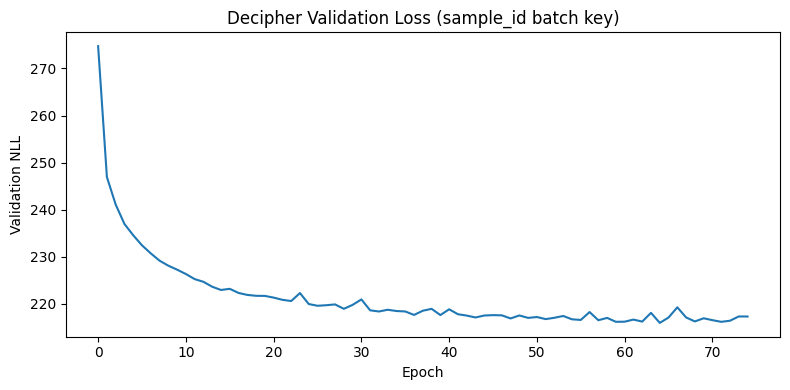

Epochs recorded: 75
First loss: 274.74
Last loss:  217.29
Min loss:   215.93 at epoch 64


In [14]:
plt.figure(figsize=(8, 4))
plt.plot(val_losses_brd4_sid)
plt.xlabel('Epoch')
plt.ylabel('Validation NLL')
plt.title('Decipher Validation Loss (sample_id batch key)')
plt.tight_layout()
plt.show()

# Quick sanity checks
print(f"Epochs recorded: {len(val_losses_brd4_sid)}")
print(f"First loss: {val_losses_brd4_sid[0]:.2f}")
print(f"Last loss:  {val_losses_brd4_sid[-1]:.2f}")
print(f"Min loss:   {min(val_losses_brd4_sid):.2f} at epoch {val_losses_brd4_sid.index(min(val_losses_brd4_sid))}")

In [15]:
#Save model
adata_tumor_dc_brd4_concat_sid.write_h5ad('trained_models/adata_tumor_subset_dc_brd4_concat_sid.h5ad')

/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/Data Analysis/.venv/lib/python3.13/site-packages/anndata/_io/utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


In [16]:
# Read model
adata_tumor_dc_brd4_concat_sid = sc.read_h5ad('trained_models/adata_tumor_subset_dc_brd4_concat_sid.h5ad')
# Shorthand for Long Column Names
nut_fusion_col = 'NUT-fusion: 0 = unkwn; 1 = BRD4-NUT; 2 = BRD3-NUT; 3 = NSD3-NUT; 4 = ZNF532-NUT; 5 = ZNF592-NUT'
biopsy_class_col = 'biopsy_site_classification (0 = unkwn; 1 = head and neck; 2 = thoracic; 3 = non-head and neck or thoracic; 4 = LN)'
# Compute differentiation scores
%pip install openpyxl
gene_sigs_df = pd.read_excel('/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/Data/tumor_differentiation_markers.xlsx', sheet_name='undiff v diff markers NC')
sc.tl.score_genes(adata_tumor_dc_brd4_concat_sid, gene_list=gene_sigs_df['undiff'], score_name='undiff_score')
sc.tl.score_genes(adata_tumor_dc_brd4_concat_sid, gene_list=gene_sigs_df['diff'], score_name='diff_score')


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


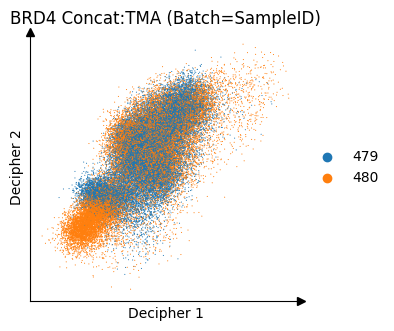

In [17]:
adata_tumor_dc_brd4_concat_sid.obs['TMA'] = adata_tumor_dc_brd4_concat_sid.obs['TMA'].astype(str).astype('category')
dc.pl.decipher(adata_tumor_dc_brd4_concat_sid, color='TMA',title='BRD4 Concat:TMA (Batch=SampleID)')

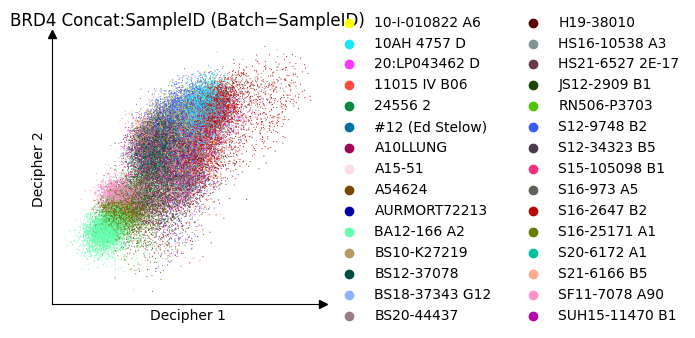

In [18]:
dc.pl.decipher(adata_tumor_dc_brd4_concat_sid, color='sample_id',title='BRD4 Concat:SampleID (Batch=SampleID)')


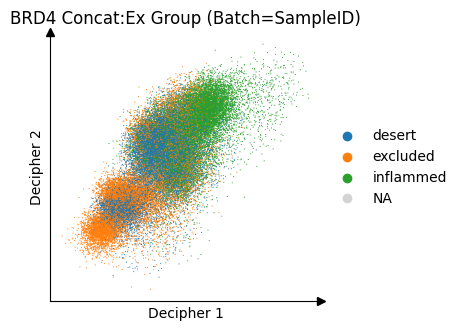

In [19]:
dc.pl.decipher(adata_tumor_dc_brd4_concat_sid, color='ex_group', title='BRD4 Concat:Ex Group (Batch=SampleID)')


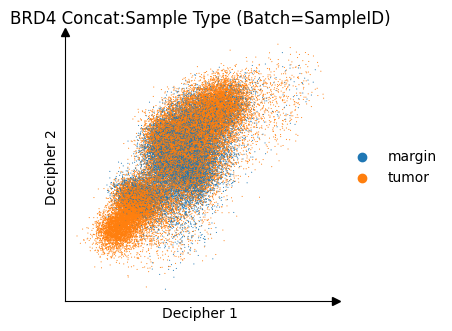

In [20]:
dc.pl.decipher(adata_tumor_dc_brd4_concat_sid, color='sample_type',title='BRD4 Concat:Sample Type (Batch=SampleID)')


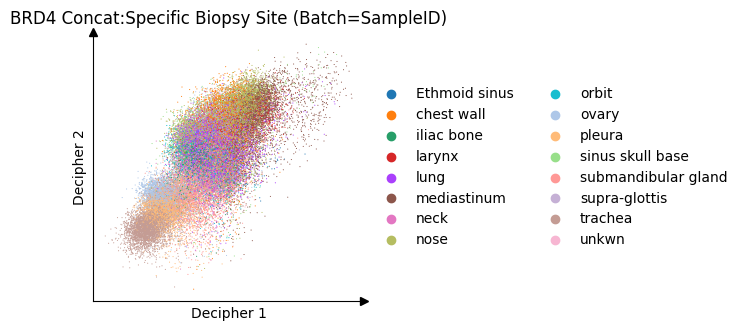

In [21]:
dc.pl.decipher(adata_tumor_dc_brd4_concat_sid, color='biopsy_site',title='BRD4 Concat:Specific Biopsy Site (Batch=SampleID)')


[1 3 2 0]


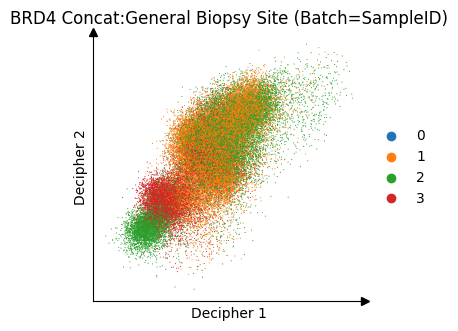

In [22]:
print(adata_tumor_dc_brd4_concat_sid.obs[biopsy_class_col].unique())
adata_tumor_dc_brd4_concat_sid.obs[biopsy_class_col] = adata_tumor_dc_brd4_concat_sid.obs[biopsy_class_col].astype(str).astype('category')
dc.pl.decipher(adata_tumor_dc_brd4_concat_sid, color=biopsy_class_col, title='BRD4 Concat:General Biopsy Site (Batch=SampleID)')


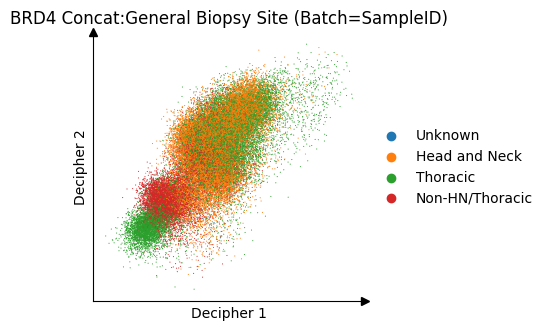

In [23]:
biopsy_class_map = {
    '0': 'Unknown',
    '1': 'Head and Neck',
    '2': 'Thoracic',
    '3': 'Non-HN/Thoracic',
    '4': 'LN'
}

adata_tumor_dc_brd4_concat_sid.obs['biopsy_site_class_labeled'] = (
    adata_tumor_dc_brd4_concat_sid.obs[biopsy_class_col].map(biopsy_class_map).astype('category')
)

dc.pl.decipher(adata_tumor_dc_brd4_concat_sid, color='biopsy_site_class_labeled', title='BRD4 Concat:General Biopsy Site (Batch=SampleID)')

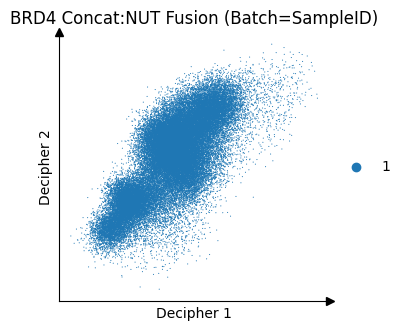

In [24]:
adata_tumor_dc_brd4_concat_sid.obs[nut_fusion_col] = adata_tumor_dc_brd4_concat_sid.obs[nut_fusion_col].astype(str).astype('category')
dc.pl.decipher(adata_tumor_dc_brd4_concat_sid, color=nut_fusion_col,title='BRD4 Concat:NUT Fusion (Batch=SampleID)')


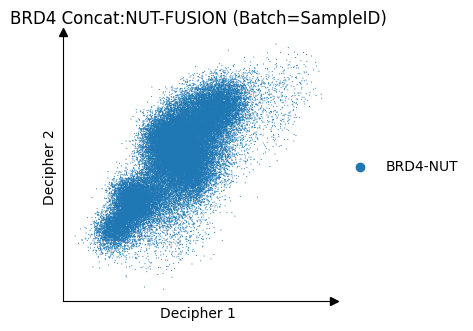

In [25]:
nut_fusion_map = {
    '0': 'Unknown',
    '1': 'BRD4-NUT',
    '2': 'BRD3-NUT',
    '3': 'NSD3-NUT',
    '4': 'ZNF532-NUT',
    '5': 'ZNF592-NUT'
}

adata_tumor_dc_brd4_concat_sid.obs['NUT_fusion_labeled'] = (
    adata_tumor_dc_brd4_concat_sid.obs[nut_fusion_col].map(nut_fusion_map).astype('category')
)

dc.pl.decipher(adata_tumor_dc_brd4_concat_sid, color='NUT_fusion_labeled', title='BRD4 Concat:NUT-FUSION (Batch=SampleID)')

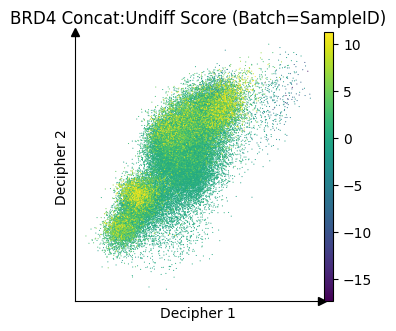

In [26]:
dc.pl.decipher(adata_tumor_dc_brd4_concat_sid, color='undiff_score',title='BRD4 Concat:Undiff Score (Batch=SampleID)')

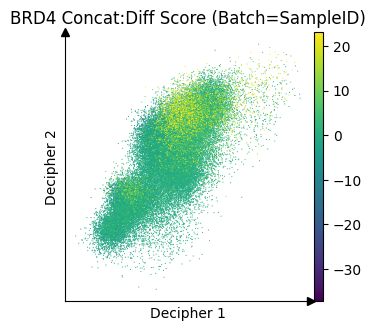

In [27]:
dc.pl.decipher(adata_tumor_dc_brd4_concat_sid, color='diff_score',title='BRD4 Concat:Diff Score (Batch=SampleID)')


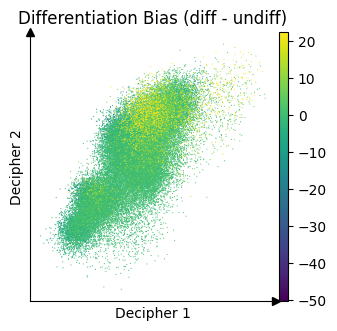

In [28]:
adata_tumor_dc_brd4_concat_sid.obs['diff_undiff_ratio'] = (
    adata_tumor_dc_brd4_concat_sid.obs['diff_score'] - adata_tumor_dc_brd4_concat_sid.obs['undiff_score']
)

dc.pl.decipher(adata_tumor_dc_brd4_concat_sid, color='diff_undiff_ratio', title='Differentiation Bias (diff - undiff)')